# 01 · Data and amenities

**Goal:** build an evaluation set of real accommodation photos where the target amenities are visible and boxed, plus photos from the same kind of room where they are not.

**Source.** All images come from trivago's internal accommodation image inventory. I limited the pull to Tier A and B properties (well-curated, commercially important listings) in Paris, Barcelona and Rome, three cities with dense and varied inventory.

**The catch.** The inventory only has coarse room tags (bathroom, bedroom, kitchen, amenities). Nothing says "this photo shows a kettle". So the dataset had to be built in steps:

1. **BigQuery:** join the image table with the property table, keep Tier A/B properties in the three cities, and filter by the room tags where each amenity usually appears (queries in [`docs/sql`](../docs/sql)).
2. **Manual review:** go through the candidates and drop duplicates, broken files, ambiguous shots and anything off-topic.
3. **Roboflow annotation:** draw a tight box around every visible instance of the amenity, one project per amenity.
4. **Negatives:** for each amenity, keep photos from the same room type where the object is absent (a bathroom without a bathtub). These measure false detections.

| Amenity | Room tags used | Why it made the cut |
|---|---|---|
| Bathtub | bathroom | big comfort factor, visually distinct |
| Kettle | bedroom, kitchen | small but decisive for many travellers |
| TV | bedroom | standard object, easy to verify |
| Hairdryer | bathroom | often asked about, small and often wall-mounted |
| Mirror | bathroom, bedroom | common, but reflective and hard to detect |

The candidate list was much longer (power sockets, microwaves, air conditioning, wardrobes). I kept amenities that passed three tests: I could build a dataset for them, they are visible in photos, and they matter to travellers.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

## Dataset summary (test split)
Counts come straight from the annotation files in `data/annotations`.

In [2]:
from amenity_qgen.detection import load_ground_truth

rows = []
for am in AMENITIES:
    gt = load_ground_truth(ROOT / "data" / "annotations" / f"{am}_test.coco.json")
    rows.append(dict(
        amenity=NAMES[am],
        images=len(gt),
        with_amenity=sum(len(v) > 0 for v in gt.values()),
        negatives=sum(len(v) == 0 for v in gt.values()),
        annotated_objects=sum(len(v) for v in gt.values()),
        images_with_2plus=sum(len(v) > 1 for v in gt.values()),
    ))
dataset = pd.DataFrame(rows)
dataset.to_csv(ROOT / "results" / "detection" / "dataset_summary.csv", index=False)
dataset

,amenity,images,with_amenity,negatives,annotated_objects,images_with_2plus
0,Bathtub,290,214,76,216,2
1,Kettle,272,201,71,201,0
2,Hairdryer,284,209,75,215,6
3,Mirror,226,226,0,279,41
4,TV,360,269,91,274,5


Mirror stands out: 41 photos contain two or more mirrors (vanity mirror, full-length mirror, mirrored wardrobe). The mirror negatives were scored in a separate pass, so none appear in this split.

## Sample annotations
One annotated test photo per amenity. Green is the ground-truth box.

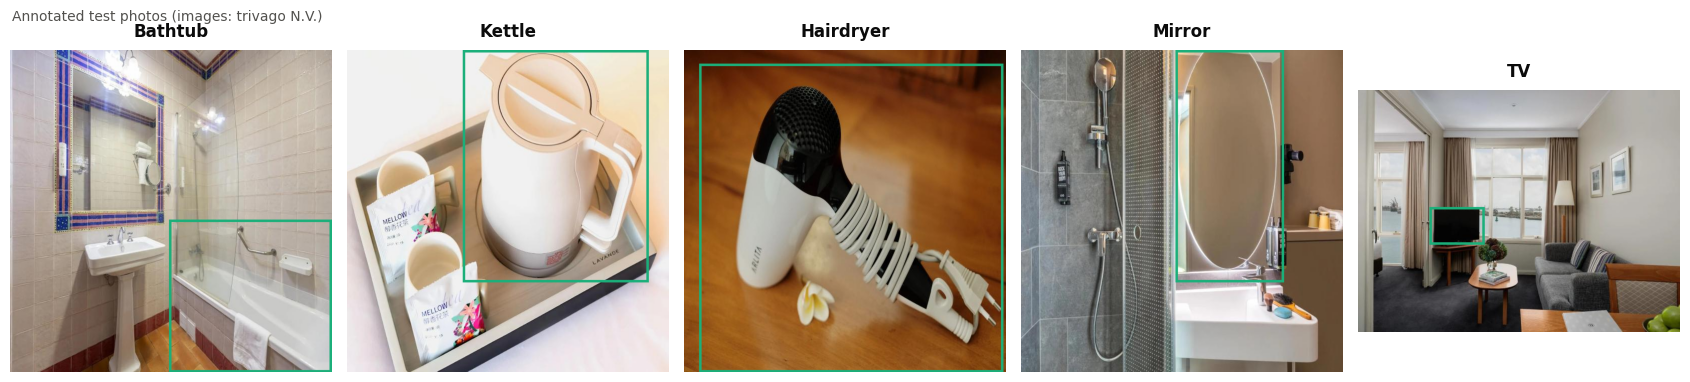

In [3]:
from PIL import Image, ImageDraw

manifest = pd.read_csv(ROOT / "data" / "sample_manifest.csv")
fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
for ax, am in zip(axes, AMENITIES):
    f = manifest[(manifest.amenity == am) & (manifest.kind == "positive")].file.iloc[0]
    gt = load_ground_truth(ROOT / "data" / "sample" / am / "_annotations.coco.json")
    img = Image.open(ROOT / "data" / "sample" / am / f).convert("RGB")
    draw = ImageDraw.Draw(img)
    for b in gt[f]:
        draw.rectangle(list(b), outline=(27, 175, 122), width=5)
    ax.imshow(img); ax.set_axis_off(); ax.set_title(NAMES[am], loc="center")
fig.suptitle("Annotated test photos (images: trivago N.V.)", x=0.01, ha="left", color=TEXT_2, fontsize=10)
plt.tight_layout()
fig.savefig(FIG / "data_sample_annotations.png", dpi=100)
plt.show()

## Takeaways
- Nothing in the inventory could be queried by amenity, so SQL got the candidates close and manual review did the rest.
- Negative images from the same room type make the false-positive numbers in notebook 02 meaningful: a bathroom without a bathtub is a much harder test than a random photo.
- The sample folder in this repo has 6 annotated photos per amenity, 2 negatives each (except mirror), and the 15 photos used in the user study.